In [1]:
import random
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)



In [22]:
csv_paths = ['data/results/n_scaling_15_10/d18_m02_y2026_n10000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n20000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n30000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n40000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n50000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n60000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n70000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n80000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n90000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n10000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n20000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n30000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n40000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n50000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n60000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n70000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n80000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n90000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n10000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n20000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n30000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n40000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n50000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n60000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n70000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n80000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n90000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n10000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n20000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n30000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n40000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n50000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n60000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n70000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n80000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n90000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n10000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n20000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n30000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n40000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n50000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n60000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n70000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n80000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n90000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n10000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n20000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n30000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n40000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n50000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n60000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n70000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n80000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n90000_redSz1_1_sd1925134378/results_sd1925134378.csv']

In [ ]:
def parse_reduce_tuple(val):
    """Parse reduce_triggerSz_sizeLim column."""
    try:
        return ast.literal_eval(str(val))
    except:
        return None

def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
    """Load and combine multiple experiment CSVs."""
    dfs = []
    for path in csv_paths:
        df = pd.read_csv(path, index_col=0)
        df['source_file'] = Path(path).parent.name 
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)

    if 'reduce_triggerSz_sizeLim' in combined.columns:
        parsed = combined['reduce_triggerSz_sizeLim'].apply(parse_reduce_tuple)
        combined['trigger_sz'] = parsed.apply(lambda x: x[0] if x else None)
        combined['size_lim']   = parsed.apply(lambda x: x[1] if x else None)
    
    return combined

In [4]:
df = load_all_csvs(csv_paths)


NameError: name 'csv_paths' is not defined

In [ ]:
def plot_n_scaling_comparison(df: pd.DataFrame):
    """
    Plot sumtest_time vs dataset_size for different reduction configs.
    Shows which configs scale better as n grows.
    """
    
    if 'dataset_size' not in df.columns or 'independent_variable' not in df.columns:
        print("  Skipping n-scaling plot: required columns not found")
        return
    
    n_scaling = df[df['independent_variable'] == 'dataset_size'].copy()
    if n_scaling.empty:
        print("  Skipping n-scaling plot: no dataset_size experiments found")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left: Time vs n
    ax = axes[0]
    for config, group in n_scaling.groupby('reduce_triggerSz_sizeLim'):
        group = group.sort_values('dataset_size')
        
        x = group['dataset_size']
        y = group['sumtest_time_mean']
        yerr = group['sumtest_time_std'] # was using sum_time_std instead of sumtest_time_std
        
        # Format label nicely
        try:
            trigger, size_lim = ast.literal_eval(str(config))
            label = f"({trigger},{size_lim})" if trigger < 1e6 else "no reduction"
        except:
            label = str(config)
        
        ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2, markersize=5, capsize=3, alpha=0.8, label=label)
    
    ax.set_xlabel('Dataset Size (n)', fontsize=12)
    ax.set_ylabel('Mean SUMTEST Time (ms)', fontsize=12)
    ax.set_title('Speed vs Dataset Size by Reduction Config\n(lower = better)', fontsize=13)
    ax.legend(fontsize=9, title='(trigger, size_lim)')
    ax.grid(True, alpha=0.3)
    
    # Right: Coverage vs n
    ax = axes[1]
    if 'result_coverage' in n_scaling.columns:
        for config, group in n_scaling.groupby('reduce_triggerSz_sizeLim'):            
            group = group.sort_values('dataset_size')
            
            x = group['dataset_size']
            y = group['result_coverage']
        
            # Format label nicely
            try:
                trigger, size_lim = ast.literal_eval(str(config))
                label = f"({trigger},{size_lim})" if trigger < 1e6 else "no reduction"
            except:
                label = str(config)
            
            ax.plot(group['dataset_size'], group['result_coverage'],marker='o', linewidth=2, markersize=5, alpha=0.8, label=label)
        
        ax.set_xlabel('Dataset Size (n)', fontsize=12)
        ax.set_ylabel('Mean Result Coverage', fontsize=12)
        ax.set_title('Coverage vs Dataset Size\n(shows overapproximation)', fontsize=13)
        ax.legend(fontsize=9, title='(trigger, size_lim)')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'result_coverage\nnot available',
               ha='center', va='center', fontsize=14, color='gray')
        ax.axis('off')
    
    fig.suptitle('N-Scaling Comparison Across Reduction Configs', fontsize=14, y=1.02)
    fig.tight_layout()
    path = './alex/' + 'trials_n_scaling_redVary.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.plot()
    # plt.close(fig)
    # print(f"  Saved: {path}")

FileNotFoundError: [Errno 2] No such file or directory: './alex/trials_n_scaling_redVary.png'

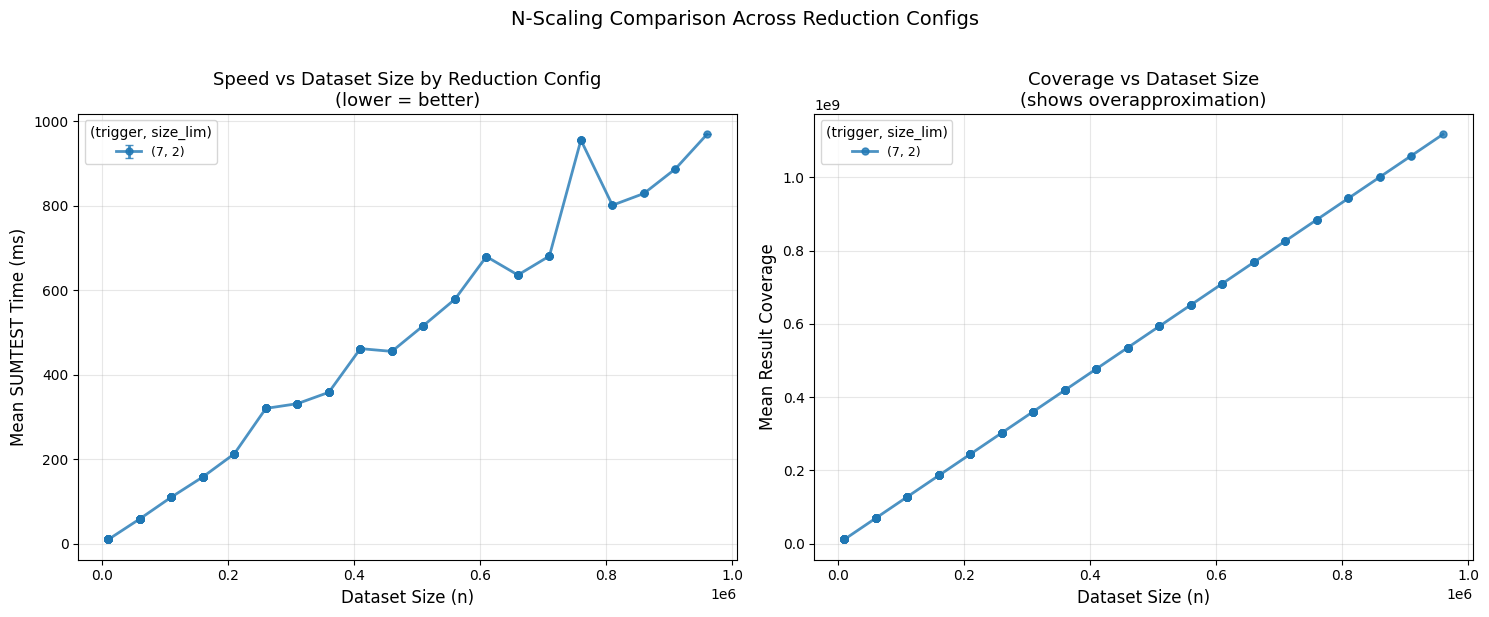

In [8]:
n1mil_scaling_7_2_csv_paths = ['data/results/n1mil_scaling_7_2/d19_m02_y2026_n_10000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_60000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_110000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_160000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_210000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_260000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_310000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_360000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_410000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_460000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_510000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_560000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_610000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_660000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_710000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_760000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_810000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_860000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_910000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_960000_7_2_sd1979149363/results_sd1979149363.csv']
df_n1mil_scaling_7_2 = load_all_csvs(n1mil_scaling_7_2_csv_paths)
plot_n_scaling_comparison(df_n1mil_scaling_7_2)

FileNotFoundError: [Errno 2] No such file or directory: './alex/trials_n_scaling_redVary.png'

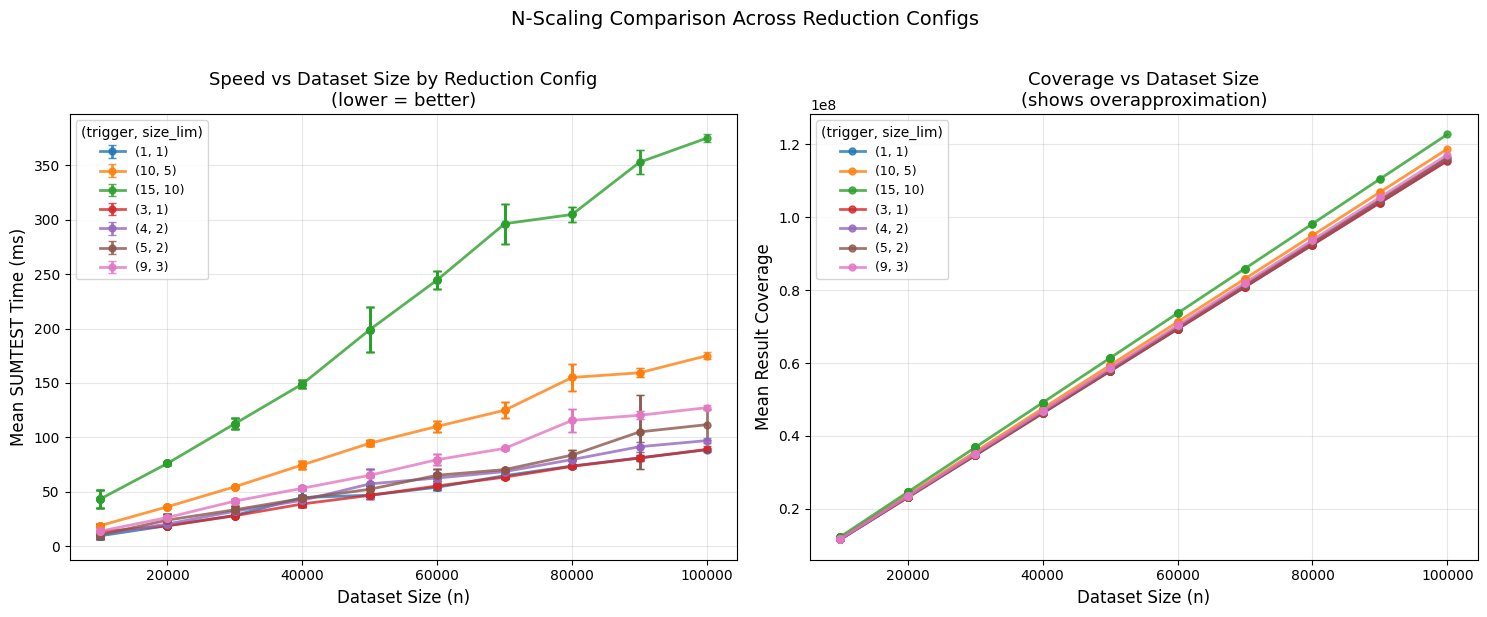

In [9]:
trials_n_scaling_redVary_csv_paths = ['data/results/n_scaling_15_10/d19_m02_y2026_n10000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n20000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n30000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n40000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n50000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n60000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n70000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n80000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n90000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n100000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n10000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n20000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n30000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n40000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n50000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n60000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n70000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n80000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n90000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n100000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n10000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n20000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n30000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n40000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n50000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n60000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n70000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n80000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n90000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n100000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n10000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n20000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n30000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n40000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n50000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n60000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n70000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n80000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n90000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n100000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n10000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n20000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n30000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n40000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n50000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n60000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n70000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n80000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n90000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n100000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n10000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n20000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n30000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n40000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n50000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n60000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n70000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n80000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n90000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n100000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n10000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n20000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n30000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n40000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n50000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n60000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n70000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n80000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n90000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n100000_redSz1_1_sd1980791682/results_sd1980791682.csv']
df_trials_n_scaling_redVary = load_all_csvs(trials_n_scaling_redVary_csv_paths)
plot_n_scaling_comparison(df_trials_n_scaling_redVary)

In [10]:
reduction_sweep_n100k_csv_paths = ['data/results/reduction_sweep/d19_m02_y2026_red_15_10_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_10_5_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_9_3_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_7_2_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_5_2_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_3_1_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_1_1_sd1988665848/results_sd1988665848.csv']
df_reduction_sweep_n100k = load_all_csvs(reduction_sweep_n100k_csv_paths)
plot_n_scaling_comparison(df_reduction_sweep_n100k)

  Skipping n-scaling plot: no dataset_size experiments found


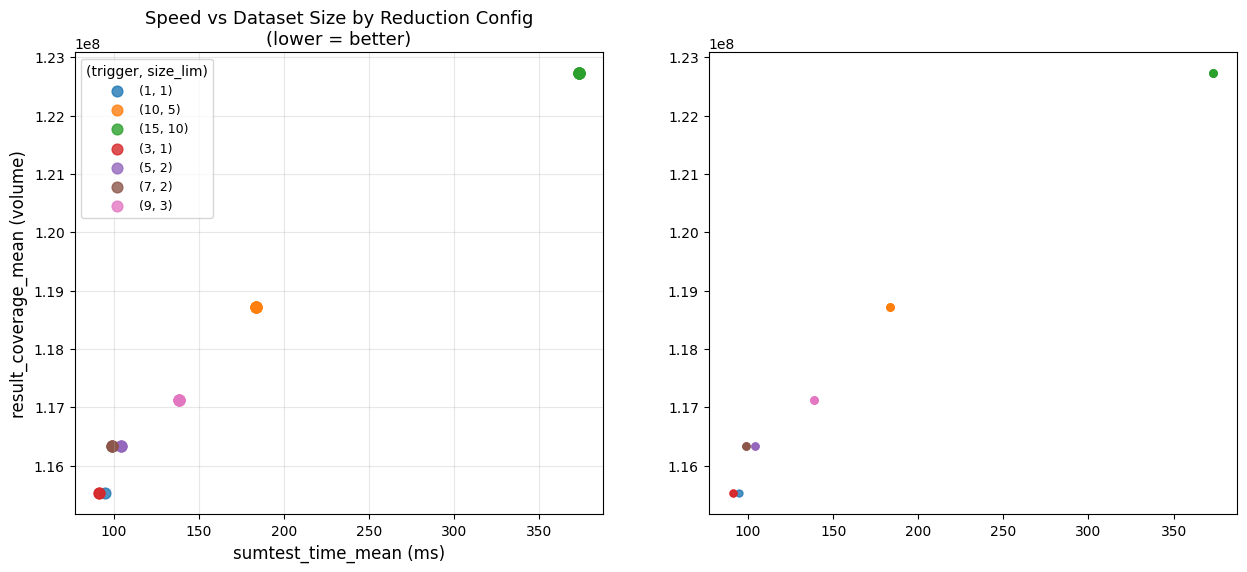

In [14]:
# df_reduction_sweep_n100k
plot_size_vs_time(df_reduction_sweep_n100k, 'reduce_triggerSz_sizeLim')

In [ ]:
def plot_size_vs_time(df: pd.DataFrame, iv: str):
    """
    Plot sumtest_time vs dataset_size for different reduction configs.
    Shows which configs scale better as n grows.
    """
    if iv not in df.columns or 'independent_variable' not in df.columns:
        print(f"  Skipping plot: no {iv} experiments found")
        return
    
    data = df[df['independent_variable'] == iv].copy()

    if data.empty:
        print(f"  Skipping plot: no {iv} experiments found")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left: Time vs Cover
    ax = axes[0]
    for config, group in data.groupby('reduce_triggerSz_sizeLim'):
        group = group.sort_values(iv)
        
        x = group['sumtest_time_mean']
        y = group['result_coverage_mean']
        # yerr = group['sumtest_time_std'] # was using sum_time_std instead of sumtest_time_std
        yerr = None


        # Format label nicely
        try:
            trigger, size_lim = ast.literal_eval(str(config))
            label = f"({trigger},{size_lim})" if trigger < 1e6 else "no reduction"
        except:
            label = str(config)
        
        # ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2, markersize=5, capsize=3, alpha=0.8, label=label)
        ax.scatter(x, y, s=60, alpha=0.8, label=label)
        axes[1].errorbar(x, y, yerr=yerr, marker='o', linewidth=2, markersize=5, capsize=3, alpha=0.8, label=label)
    
    ax.set_xlabel('sumtest_time_mean (ms)', fontsize=12)
    ax.set_ylabel('result_coverage_mean (volume)', fontsize=12)
    ax.set_title('Speed vs Dataset Size by Reduction Config\n(lower = better)', fontsize=13)
    ax.legend(fontsize=9, title='(trigger, size_lim)')
    ax.grid(True, alpha=0.3)
    
    # # Right: Coverage vs n
    # ax = axes[1]
    # if 'result_coverage' in data.columns:
    #     for config, group in data.groupby('reduce_triggerSz_sizeLim'):            
    #         group = group.sort_values('dataset_size')
            
    #         x = group['dataset_size']
    #         y = group['result_coverage']
        
    #         # Format label nicely
    #         try:
    #             trigger, size_lim = ast.literal_eval(str(config))
    #             label = f"({trigger},{size_lim})" if trigger < 1e6 else "no reduction"
    #         except:
    #             label = str(config)
            
    #         ax.plot(group['dataset_size'], group['result_coverage'],marker='o', linewidth=2, markersize=5, alpha=0.8, label=label)
        
    #     ax.set_xlabel('Dataset Size (n)', fontsize=12)
    #     ax.set_ylabel('Mean Result Coverage', fontsize=12)
    #     ax.set_title('Coverage vs Dataset Size\n(shows overapproximation)', fontsize=13)
    #     ax.legend(fontsize=9, title='(trigger, size_lim)')
    #     ax.grid(True, alpha=0.3)
    # else:
    #     ax.text(0.5, 0.5, 'result_coverage\nnot available',
    #            ha='center', va='center', fontsize=14, color='gray')
    #     ax.axis('off')
    
    # fig.suptitle('N-Scaling Comparison Across Reduction Configs', fontsize=14, y=1.02)
    # fig.tight_layout()
    path = './graphics/' + 'timeVScoverage_varyRED.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.plot()
    # plt.close(fig)
    # print(f"  Saved: {path}")

In [12]:
def pareto_frontier(df, x=None, y=None, maximize_x=False, maximize_y=False):
    x = df['sumtest_time_mean']
    y = df['result_coverage_mean']
    # x = time, y = size/inflation
    # minimize both by default
    points = np.array(list(zip(x, y)))
    print(points)
    
    frontier = []
    for p in points:
        dominated = False
        for q in points:
            if (q[0] <= p[0] and q[1] <= p[1]) and (q[0] < p[0] or q[1] < p[1]):
                dominated = True
                break
        if not dominated:
            frontier.append(p)
    return np.array(frontier)


In [13]:
frontier = pareto_frontier(df_reduction_sweep_n100k)

[[3.73175400e+02 1.22722174e+08]
 [3.73175400e+02 1.22722174e+08]
 [1.83412800e+02 1.18722138e+08]
 [3.73175400e+02 1.22722174e+08]
 [1.83412800e+02 1.18722138e+08]
 [1.38474000e+02 1.17122121e+08]
 [3.73175400e+02 1.22722174e+08]
 [1.83412800e+02 1.18722138e+08]
 [1.38474000e+02 1.17122121e+08]
 [9.88388000e+01 1.16330985e+08]
 [3.73175400e+02 1.22722174e+08]
 [1.83412800e+02 1.18722138e+08]
 [1.38474000e+02 1.17122121e+08]
 [9.88388000e+01 1.16330985e+08]
 [1.04114800e+02 1.16330985e+08]
 [3.73175400e+02 1.22722174e+08]
 [1.83412800e+02 1.18722138e+08]
 [1.38474000e+02 1.17122121e+08]
 [9.88388000e+01 1.16330985e+08]
 [1.04114800e+02 1.16330985e+08]
 [9.09306000e+01 1.15522355e+08]
 [3.73175400e+02 1.22722174e+08]
 [1.83412800e+02 1.18722138e+08]
 [1.38474000e+02 1.17122121e+08]
 [9.88388000e+01 1.16330985e+08]
 [1.04114800e+02 1.16330985e+08]
 [9.09306000e+01 1.15522355e+08]
 [9.44544000e+01 1.15522355e+08]]
